## Naive State Prep Tutorial

In this example notebook, we will walk through 4 examples:
1. Naive state prep for real positive coefficients
2. Naive state prep for complex coefficients (sequential Ry muxs followed by sequential Rz muxs)
3. Naive state prep for complex coefficients (sequential Ry muxs followed by a single phase mux with ancilla qubit)
4. Controlled naive state prep for complex coefficients
5. Naive state prep for real coefficients (including negative)

__Introduction:__

A [method for loading arbitrary quantum states](https://arxiv.org/pdf/quant-ph/0407010.pdf) is generally referred to as naive state preparation. 

The idea is the following: say you have an $n$-qubit all-zero state, and you want to prepare an orthonormal $n$-qubit state of the following form:

$$ |\psi\rangle = \frac{1}{|\vec{a}|_2}\sum_{i = 0}^{2^n - 1}a_{i}|i\rangle$$

What you can do is perform a single-qubit rotation $e^{-iY\cos^{-1}p_0}$ (where $p_0$ is obtained by some function of $\vec{a}$) on the most significant bit of your all-zero state. Then, conditioned on that qubit, you perform another series of rotations (also by angles which are obtained via functions of $\vec{a}$) on the second most significant bit. You then continue to recursively apply $m$-controlled rotations conditioned on the previous $m$ bits. This looks something like:

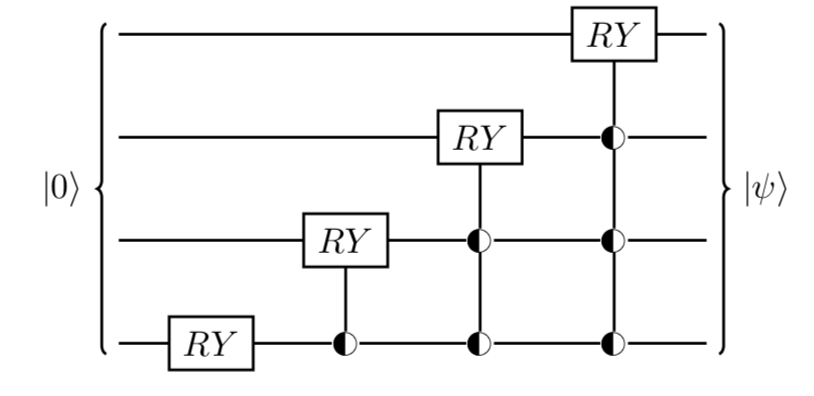

Naïvely this decomposes into $2^n - 1$ rotations, each of which then has to be decomposed into some number of $\text{T}$ gates.

### Uniformly-controlled rotations, or "multiplexed" rotations

The above circuit makes use of a cascading series of uniformly-controlled rotations. These are gates which work as follows: give me an index `x`, and I apply the `x`th rotation from some list of angles. Mathematically, this is the operation:

$$U = \sum_{x = 0}^{2^n - 1} |x\rangle \langle x| \otimes e^{2\pi i \theta_x Y}$$

The most naïve implementation of this operation looks as follows:

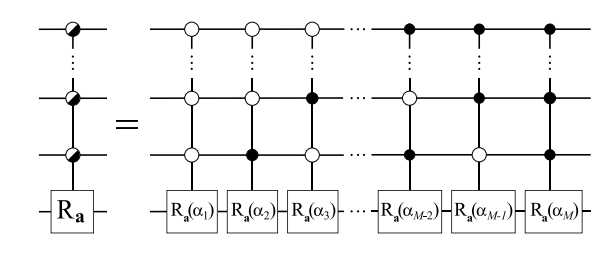

First we need the following import statements:

In [ ]:
import numpy as np

from psiqworkbench import QPU, Qubits
from workbench_algorithms.experimental.subroutines import (
    ArbitraryStatePrep,
    FlattenedRotArray,
    NaiveMultiplexedSingleQubitRotation,
    ProgrammableRotArray,
)
from workbench_algorithms.experimental.utils import (
    ArbitraryStatePrepData,
    SupportedOps,
    generate_complex_array,
)
from psiqworkbench.utils.numpy_utils import fidelity

#### Use Dictionary to Pull Out the State From Register

Let's define a customized method to pull states from quantum registers for convenience (current version is slow and does not handle global phase well) since we need to pull states from a subset of the state vector output.

__Warning__: this could be removed after either the original `pull_state(qreg)` method is greatly improved to match the performance and fix the global phase issue, or some version of the code below is integrated in some sort of ways.

In [ ]:
def pull_state_improved(qreg: Qubits) -> np.ndarray:
    """Method to pull out state for a given quantum register

    Args:
        qreg: A Qubits object tracked by a QPU

    Returns:
        np.ndarray: Complex state vector output
    """
    qc = qreg.qpu
    qc_state_dict = qc.pull_state(with_qreg_labels=True)
    allocated_qreg_names = qc_state_dict["qregs"]
    allocated_qreg_amps = qc_state_dict["amps"]

    try:
        reg_idx = allocated_qreg_names.index(qreg.name)
    except ValueError:
        raise ValueError(f"QReg {qreg.name} not found in QPU state.")

    qreg_amplitudes = {}
    for basis_tuple, amp in allocated_qreg_amps.items():
        local_basis = basis_tuple[reg_idx]
        qreg_amplitudes[local_basis] = amp

    # Normalize keys to bitstrings
    first_key = next(iter(qreg_amplitudes))
    if isinstance(first_key, str):
        num_qubits = len(first_key)
    else:
        # Convert int keys like 3 → '011'
        max_index = max(qreg_amplitudes)
        num_qubits = max_index.bit_length()

    dim = 2 ** num_qubits
    state_vector = np.zeros(dim, dtype=complex)

    for k, amp in qreg_amplitudes.items():
        if isinstance(k, str):
            index = int(k, 2)
        else:
            index = k
        state_vector[index] = amp
        
    return state_vector

### Example 1: Naive State Prep with Positive Real Coefficients

Let's setup a small instance where we can run the quantum circuit simulator.

We want the `ArbitraryStatePrep` circuit to create a 3-qubit state arbitrary state for us (all amplitudes are real positive):

$|\psi_1\rangle = \frac{1}{||\vec{a}||}\sum_{i = 0}^{7}a_i|i\rangle$, $a_i \in \mathbb{R^+}$

You can see that the code below is generating all the controlled-Ry gates as shown above, with the rotation angles computed in degrees.

In [ ]:
# number of coefficients
num_coeffs = 8

# get a (seeded) randomized real positive array of size 8)
np.random.seed(42)
coeffs = [np.random.rand() for _ in range(num_coeffs)]
norm = sum(abs(amp) ** 2 for amp in coeffs)
normalized_coeffs = [amp / np.sqrt(norm) for amp in coeffs]

# pass the normalized array into the data class
data_1 = ArbitraryStatePrepData(normalized_coeffs, 999999999)  # inserting a big number to comply with syntax, to be optimized in the future, as Naive and Gray Code don't need bit precision param

# set up QPU simulator
qc = QPU()
num_prep = int(np.ceil(np.log2(num_coeffs)))
qc.reset(num_prep)
target_reg = Qubits(num_prep, "target_reg", qc)

# Use naive state prep instance by setting the mux instance
mplxr_instance = NaiveMultiplexedSingleQubitRotation()
mux_rot = ProgrammableRotArray(op=SupportedOps.RY, mplxr=mplxr_instance)

# call ArbitraryStatePrep object and do .compute to execute the circuit operation
state_prep = ArbitraryStatePrep(mux_rot)
state_prep.compute(target_reg, data_1)

qc.draw()

# display input + output to compare
input_array = np.array(normalized_coeffs)
output_array = pull_state_improved(target_reg) # use the dictionary method to pull out output state vec from target_reg
print(np.allclose(input_array, output_array)) # check if the output array is exactly the same as the input array
print(input_array)
print(np.real(output_array)) # cast to real array since there are some 1e-17 phase error in WB simulator


### Example 2: Naive State Prep with Complex Coefficients - Programmable Rot Array Version

Now let's use `ArbitraryStatePrep` circuit to create a 3-qubit state arbitrary state with complex state vector input:

$\ket{\psi_2} = \frac{1}{||\vec{a}||}\sum_{i = 0}^{7}a_i\ket{i}$, $a_i \in \mathbb{C}$

The way this version works is by concatenating another layer of Rz muxs that fix the phases following the Ry muxs which first compute the amplitudes.

__Warning:__ there is a global phase difference in the output. Unless you _really_ want to save that ancilla qubit, please consider using the method in example 3 to avoid confusions during debugging.

In [ ]:
# number of coefficients
num_coeffs = 8

# get a (seeded) randomized complex array of size 8)
np.random.seed(42)
coeffs = generate_complex_array(num_coeffs)
norm = sum(abs(amp) ** 2 for amp in coeffs)
normalized_coeffs = [amp / np.sqrt(norm) for amp in coeffs]

# pass the normalized array into the data class
data_2 = ArbitraryStatePrepData(normalized_coeffs, 999999999)  # inserting a big number to comply with syntax, to be optimized in the future, as Naive and Gray Code don't need bit precision param

# set up QPU simulator
qc = QPU()
num_prep = int(np.ceil(np.log2(num_coeffs)))
qc.reset(num_prep)
target_reg = Qubits(num_prep, "target_reg", qc)

# Use naive state prep instance by setting the mux instance for the real part
mplxr_instance = NaiveMultiplexedSingleQubitRotation()
mux_rot = ProgrammableRotArray(op=SupportedOps.RY, mplxr=mplxr_instance)
# Use sequencial Rz muxs (programmable rot array) instance to load in the phases
mux_rot_phase = ProgrammableRotArray(op=SupportedOps.RZ, mplxr=mplxr_instance)

# call ArbitraryStatePrep object and do .compute to execute the circuit operation
state_prep = ArbitraryStatePrep(mux_rot, mux_rot_phase)
state_prep.compute(target_reg, data_2) # passing in the data instance generated above

qc.draw()

# display input + output to compare
input_array = np.array(normalized_coeffs)
output_array = pull_state_improved(target_reg)
print(fidelity(input_array, output_array)) # dot product square should equal 1 (accounting for global phase)
print(input_array)
print(output_array) # notice there is a slight difference due to global phase

### Example 3: Naive State Prep with Complex Coefficients - Flattened Rot Array Version

We now use a different implementation to prep the same state we were just looking at above in example 2:

$\ket{\psi_2} = \frac{1}{||\vec{a}||}\sum_{i = 0}^{7}a_i\ket{i}$, $a_i \in \mathbb{C}$

The idea is to first use the Ry muxs to load in the amplitudes (same as before), then use a single bigger mux to load in all the phases, with the help of one ancilla qubit.

In [ ]:
# set up QPU simulator
qc = QPU()
qc.reset(num_prep + 1) # use the same num of target qubits, plus one ancilla qubit
target_reg = Qubits(num_prep, "target_reg", qc)

# Use naive state prep instance by setting the mux instance for the real part
mplxr_instance = NaiveMultiplexedSingleQubitRotation()
mux_rot = ProgrammableRotArray(op=SupportedOps.RY, mplxr=mplxr_instance)
# Use single Rz mux (flattened rot array) instance to load in the phases
mux_rot_phase = FlattenedRotArray(mplxr=mplxr_instance)
state_prep = ArbitraryStatePrep(mux_rot, mux_rot_phase)

state_prep.compute(target_reg, data_2) # use the same data as above

qc.draw()

# display input + output to compare
input_array = np.array(normalized_coeffs)
output_array = pull_state_improved(target_reg)
print(np.allclose(input_array, output_array)) # check if the output array is exactly the same as the input array
print(input_array)
print(output_array)

### Example 4: Controlled Naive State Prep with Complex Coefficients - Programmable Rot Array Version

Lastly, let's take a look how to set up the controlled naive state prep. That is, we seek the following operation:

$U_{CSP}((\alpha|0\rangle + \beta|1\rangle)|0^n\rangle) = \alpha|0\rangle|0^n\rangle + \beta|1\rangle|\psi\rangle$

(The controll registers can also be generated to qubit count > 1)

Now we will look at a case where we want to do:

$U_{CSP}((\alpha|0\rangle + \beta|1\rangle)|0^3\rangle) = \alpha|0\rangle|0^3\rangle + \beta|1\rangle|\frac{1}{||\vec{a}||}\sum_{i = 0}^{7}a_i\ket{i}$, $a_i \in \mathbb{C}$

Let's do the same set up as in example 2, but now include another control register to host the control bit.

__Note:__ the sequential Rz mux version also does not contain a global phase since we have added fix up gate. Feel free to also use that by replacing line 14 with line 16 below if you want to save the ancilla qubit.

In [ ]:
# number of control bits
num_ctrl = 1

# set up QPU simulator
qc = QPU()
qc.reset(num_prep + num_ctrl + 1) # Note: current version need +1 for num_ctrl > 1, can refactor if needed (e.g., simplify control gates)
ctrl_reg = Qubits(num_ctrl, "ctrl", qc) # setup control register
target_reg = Qubits(num_prep, "target_reg", qc)

# Use naive state prep instance by setting the mux instance for the real part
mplxr_instance = NaiveMultiplexedSingleQubitRotation()
mux_rot = ProgrammableRotArray(op=SupportedOps.RY, mplxr=mplxr_instance)
# Use single Rz mux (flattened rot array) instance to load in the phases
mux_rot_phase = FlattenedRotArray(mplxr=mplxr_instance)
# Use sequencial Rz muxs (programmable rot array) instance to load in the phases
# mux_rot_phase = ProgrammableRotArray(op=SupportedOps.RZ, mplxr=mplxr_instance)
state_prep = ArbitraryStatePrep(mux_rot, mux_rot_phase)

# do control gate(s)
ctrl_reg.x()
state_prep.compute(target_reg, data_2, ctrl_reg) # use the same data as above
# uncompute control gate(s)
ctrl_reg.x()

qc.draw()

# display input + output to compare
input_array = np.array(normalized_coeffs)
output_array = pull_state_improved(target_reg)
print(np.allclose(input_array, output_array)) # check if the output array is exactly the same as the input array
print(input_array)
print(output_array) # no global phase diff

### Example 5: Naive State Prep with Negative Real Coefficients - Flattened Rot Array Version

You may wonder, what if we have only negative real values in the input:

$\ket{\psi_{3a}} = \frac{1}{||\vec{a}||}\sum_{i = 0}^{7}a_i\ket{i}$, $a_i \in \mathbb{R}$

You can think of negative real cofficients as a special case of the complex "phases".

We can just copy and paste the exact code above in example 3 and swap out the input.

__Note:__ you can also try out the method above in example 2, but you will see that everything will be in the complex domain (big global phase diff)

In [ ]:
# get a (seeded) randomized complex array of size 8)
def generate_real_array(n: int, seed: int = None) -> np.ndarray:
    """Generates an array of size n with real values in [-1, 1].

    Args:
        n (int): Size of the array.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        np.ndarray: Real-valued array of shape (n,) with values in [-1, 1].
    """
    if seed is not None:
        np.random.seed(seed)
    return np.random.uniform(-1, 1, size=n)
np.random.seed(42)
coeffs = generate_real_array(num_coeffs)
norm = sum(abs(amp) ** 2 for amp in coeffs)
normalized_coeffs = [amp / np.sqrt(norm) for amp in coeffs]

# pass the normalized array into the data class
data_3a = ArbitraryStatePrepData(normalized_coeffs, 999999999)  # inserting a big number to comply with syntax, to be optimized in the future, as Naive and Gray Code don't need bit precision param

# set up QPU simulator
qc = QPU()
qc.reset(num_prep + 1) # use the same num of target qubits, plus one ancilla qubit
target_reg = Qubits(num_prep, "target_reg", qc)

# Use naive state prep instance by setting the mux instance for the real part
mplxr_instance = NaiveMultiplexedSingleQubitRotation()
mux_rot = ProgrammableRotArray(op=SupportedOps.RY, mplxr=mplxr_instance)
# Use single Rz mux (flattened rot array) instance to load in the phases
mux_rot_phase = FlattenedRotArray(mplxr=mplxr_instance)
state_prep = ArbitraryStatePrep(mux_rot, mux_rot_phase)

state_prep.compute(target_reg, data_3a) # use the same data as above

qc.draw()

# display input + output to compare
input_array = np.array(normalized_coeffs)
output_array = pull_state_improved(target_reg)
print(np.allclose(input_array, output_array)) # check if the output array is exactly the same as the input array
print(input_array)
print(np.real(output_array)) # cast to real array since there are some 1e-17 phase error in WB simulator